In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load the graph
import networkx as nx
G = nx.read_gml('../data/graph/LEMD_EGLL_2023_04_01.gml')
# Load node ID mappings
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

In [3]:
# Shortest path from LEMD to EGLL
shortest_path = nx.shortest_path(G, source='LEMD', target='EGLL')
print(shortest_path)

['LEMD', 'LETP', 'KOVAK', 'EGLL']


In [4]:
import numpy as np
# Load the backward value functions
V_final_bw = np.load('../data/results/backward_opt/V_final_bw.npy')
eta_final_bw = np.load('../data/results/backward_opt/eta_final_bw.npy')
alt_final_bw = np.load('../data/results/backward_opt/alt_final_bw.npy')
phase_final_bw = np.load('../data/results/backward_opt/phase_final_bw.npy')
V_final_margin_bw = np.array([np.sum(row[np.isfinite(row)]) for row in V_final_bw])

# Inspection

In [5]:
V_final_bw[node_to_idx['LFDA']]

array([       inf,        inf,        inf,        inf,        inf,
       0.01860439, 0.01791916, 0.01682187, 0.01641534, 0.01544295,
       0.01464182, 0.01391524, 0.01297664, 0.01254626, 0.01180409,
       0.01085497, 0.01017549, 0.00941399, 0.00871677, 0.00769023,
       0.00688513, 0.00624814, 0.00555358, 0.00469768, 0.00466863,
              inf,        inf,        inf,        inf,        inf,
              inf])

In [6]:
V_final_bw[node_to_idx['LETP']]

array([0.02216953, 0.02140147, 0.02065793, 0.0197552 , 0.01901405,
       0.01827013, 0.01744677, 0.01670287, 0.01595351, 0.01518712,
       0.01414603, 0.01355094, 0.01252682, 0.01205522, 0.01142868,
       0.01009285, 0.00972331, 0.00896022, 0.00815864, 0.00734173,
       0.00663231, 0.00630239,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf])

In [7]:
V_final_bw[node_to_idx['EGLL']]

array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf,  0.])

In [8]:
print(V_final_bw[node_to_idx['LEMD']])
print(eta_final_bw[node_to_idx['LEMD']])

[0.02206359 0.02120293 0.02050577 0.01970036 0.01893252 0.01806381
 0.01736008 0.01657449 0.0158081  0.01484478 0.01424969 0.0132092
 0.01259812 0.01165301 0.01076936 0.01016304 0.00934911 0.00859148
 0.00794466 0.00717943 0.00673431 0.00673277        inf        inf
        inf        inf        inf        inf        inf        inf
        inf]
[25483.99228107 26094.94587784 26670.20447415 27299.53567144
 27826.39806155 28452.66330805 28985.25045563 29681.24395069
 30286.78449076 30848.52833947 31324.30905392 32008.92230539
 32691.23771971 33213.3034169  33887.83084271 34489.39537159
 35099.98943671 35648.39209366 36294.77094303 36850.86781418
 37489.24265073 37517.68753106            nan            nan
            nan            nan            nan            nan
            nan            nan            nan]


In [9]:
print(V_final_bw[node_to_idx['LETP']])
print(eta_final_bw[node_to_idx['LETP']])



[0.02216953 0.02140147 0.02065793 0.0197552  0.01901405 0.01827013
 0.01744677 0.01670287 0.01595351 0.01518712 0.01414603 0.01355094
 0.01252682 0.01205522 0.01142868 0.01009285 0.00972331 0.00896022
 0.00815864 0.00734173 0.00663231 0.00630239        inf        inf
        inf        inf        inf        inf        inf        inf
        inf]
[25436.67279321 26053.03813289 26618.56637817 27272.65115006
 27876.31475061 28488.33229657 29089.90286752 29618.09052212
 30219.9907488  30830.26063862 31453.2948987  31932.5700355
 32610.84293938 33288.37203441 33774.92781527 34479.94917182
 34894.53369603 35539.43168965 36203.49981214 36797.44538998
 37457.76244978 37904.95144676            nan            nan
            nan            nan            nan            nan
            nan            nan            nan]


In [10]:
from equinox.helpers.datetimeh import seconds_since_midnight_to_datestr
takeoff_ssm = np.nanmax(eta_final_bw[node_to_idx['LEMD']])
print(f'Takeoff SSM: {takeoff_ssm}')
takeoff_str = seconds_since_midnight_to_datestr("2023-04-01", takeoff_ssm)
print(f'Take off at LEMD: {takeoff_str}')

Takeoff SSM: 37517.68753105525
Take off at LEMD: 2023-04-01 10:25:17


In [11]:
# Load the distance matrix
dist_matrix = np.load('../data/graph/LEMD_EGLL_2023_04_01_distances.npy')

# Load the airspace charges matrix
ac_matrix = np.load('../data/graph/LEMD_EGLL_2023_04_01_charges.npy')

node_to_idx = {node_id: i for i, node_id in enumerate(G.nodes())}

# Sample a Route

In [16]:
import importlib
import equinox.sampling.sample_route
importlib.reload(equinox.sampling.sample_route)
from equinox.sampling.sample_route import sample_routes
from equinox.sampling.sample_route import sample_routes
from equinox.cost.cost_model_1 import cost_model_1
from equinox.wind.wind_date import WindDate
import torch 
from equinox.vnav.vnav_performance import Performance, get_eta_and_distance_climb
from equinox.vnav.vnav_profiles_rev1 import NARROW_BODY_JET_CLIMB_PROFILE, NARROW_BODY_JET_DESCENT_PROFILE, NARROW_BODY_JET_CLIMB_VS_PROFILE, NARROW_BODY_JET_DESCENT_VS_PROFILE
narrow_body_jet_performance = Performance(
    climb_speed_profile=NARROW_BODY_JET_CLIMB_PROFILE,
    descent_speed_profile=NARROW_BODY_JET_DESCENT_PROFILE,
    climb_vertical_speed_profile=NARROW_BODY_JET_CLIMB_VS_PROFILE,
    descent_vertical_speed_profile=NARROW_BODY_JET_DESCENT_VS_PROFILE,
    cruise_altitude_ft=35000.0,
    cruise_speed_kts=450.0
)

climb_perf_table = get_eta_and_distance_climb(
    narrow_body_jet_performance,
    origin_airport_elevation_ft=0
)

wind_model = WindDate(date_str="2024-04-01", data_dir='../data/era5')

device = torch.device("cpu")

routes = sample_routes(
    graph=G,
    landing_time_str="2023-04-01 12:00:00", # must be same as in the backward DP process
    max_flight_duration_hours=5, # must be same as in the backward DP process
    takeoff_time_str=takeoff_str, # must be from the latest take-off time from the backward DP values (see above)
    dist_matrix_np=dist_matrix,
    ac_matrix_np=ac_matrix,
    wind_model=wind_model,
    V_bwd = torch.tensor(V_final_bw, dtype=torch.float64, device=device),
    source_node_id='LEMD',
    goal_node_id='EGLL',
    cost_model=cost_model_1,
    performance_model=narrow_body_jet_performance,
    source_elevation_ft=0,
    initial_alt_ft_amsl=0,
    delta_t_seconds=600, # must be same as in the backward DP process
    device_str="cpu",
    num_samples=20,
    temperature=1e-6
)

Node LEMD (idx 185), time bin is 21: backward val V_bwd_u_ku: 0.00673276756034349
LETP, alt: 20512.757583199007, eta: 38032.38272749597, phase: 0, log_prob_val: -9.354003917184765e-06
k_v: 21/31, V_bwd_u_ku: 0.00673276756034349, V_bwd_v_kv: 0.006302388312747689
cost_uv_val: 0.00043973325151298566
---
LFDA, alt: 35000.0, eta: 39594.57126358433, phase: 1, log_prob_val: -0.0003757924759910146
k_v: 24/31, V_bwd_u_ku: 0.00673276756034349, V_bwd_v_kv: 0.004668626787196229
cost_uv_val: 0.0024399332491382756
---
Node SIE_06 (idx 258), time bin is 21: backward val V_bwd_u_ku: 0.006350612130965369
Node BLV (idx 536), time bin is 23: backward val V_bwd_u_ku: 0.005008624187794377
Node DIKRO (idx 89), time bin is 28: backward val V_bwd_u_ku: 0.0011633502193842485
Node TELTU (idx 527), time bin is 29: backward val V_bwd_u_ku: 0.00041565408159157367
Node MID (idx 194), time bin is 29: backward val V_bwd_u_ku: 0.00026177415087149443
Node IMVUR (idx 505), time bin is 29: backward val V_bwd_u_ku: 0.0001

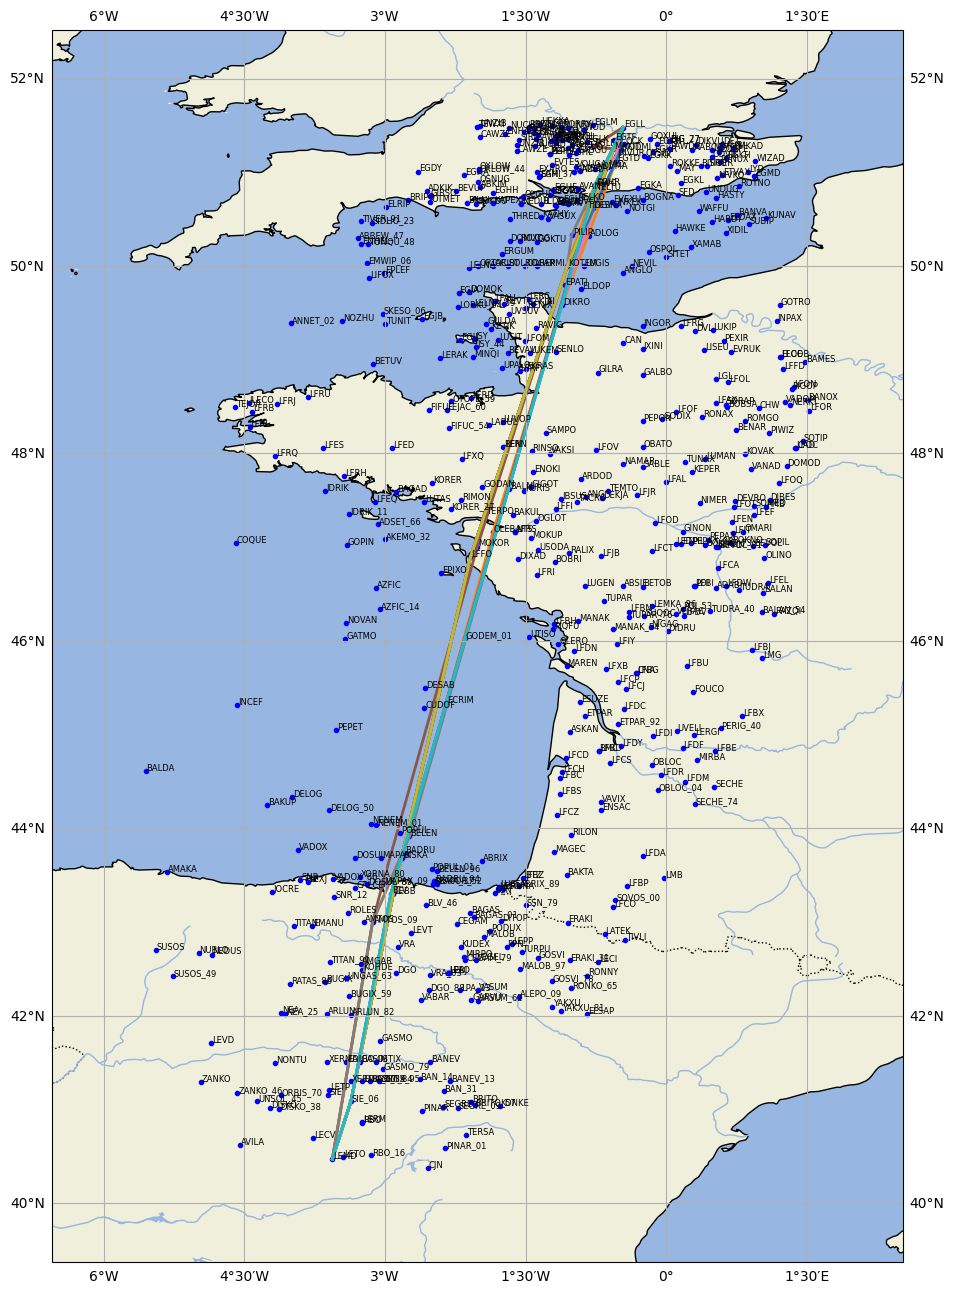

In [17]:
from equinox.helpers.plotters import plot_routes_on_map

plot_routes_on_map(G, routes)
